In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import sqlite3

In [74]:
conn=sqlite3.connect('customer_churn.db')

sql_query='''  
  select name
  from sqlite_master
  where type='table'


'''

tables=pd.read_sql(sql_query,conn)

# create dataframes for each tables

for table_name in tables['name']:
    df=pd.read_sql(f"select * from {table_name}",conn)
    globals()[f"df_{table_name}"]=df
    print(f"created dataframes:df_{table_name}")

conn.close()

created dataframes:df_db_customer
created dataframes:df_db_subscription
created dataframes:df_db_support


In [75]:
df_db_customer['dob']=pd.to_datetime(df_db_customer['dob'])


In [76]:
# 1.drop column pincode and interest
#2. Rename gender-{Men:Male,Women:Female}
#3.Finding missing values-in country
#4.Rename-name to customer_name

In [77]:
df_db_customer.drop(columns=['interests', 'pincode'], inplace=True)

In [78]:
df_db_customer['gender']=df_db_customer['gender'].replace({'Men':'Male','Women':'Female'})

In [79]:
df_db_customer.rename(columns={'name':'customer_name'},inplace=True)


In [126]:
# country and state -unique value pair
state_mapping=df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
df_db_customer['country']=df_db_customer['country'].fillna(df_db_customer['state'].map(state_mapping))


In [82]:
#Renewal_date change datatype
#cancellation_date change datatype

In [83]:
df_db_subscription['renewal_date']=pd.to_datetime(df_db_subscription['renewal_date'])

In [84]:
df_db_subscription['cancellation_date']=pd.to_datetime(df_db_subscription['cancellation_date']  )

In [85]:
df_db_subscription['subscription_start_date']=pd.to_datetime(df_db_subscription['subscription_start_date'])

In [86]:
# df_db_subscription=df_db_subscription.drop(df_db_subscription.columns[-1:],axis=1)

In [87]:
df_db_support=df_db_support.drop(columns=['col_1'])

In [88]:
df_db_support['complaint_date']=pd.to_datetime(df_db_support['complaint_date'])

In [89]:
# Feature Engineering and data analysis

In [90]:
# create a new col using existing col
df_db_subscription['churn_flag']=np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [92]:
df_db_subscription.shape

(21, 12)

In [93]:
df=(df_db_subscription.merge(df_db_customer,on='customerid',how='left').merge(df_db_support,on='customerid',how='left'))

In [94]:
df.shape

(23, 21)

In [95]:
df_db_subscription['customerid'].nunique()

21

In [96]:
df_db_subscription['customerid'].size

21

In [97]:
df_db_customer['customerid'].nunique()

21

In [98]:
df_db_subscription['customerid'].size

21

In [99]:
df_db_support['customerid'].nunique()

7

In [100]:
df_db_support['customerid'].size

9

In [101]:
df_db_support['complaint_count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [102]:
df_db_support

,customerid,complaint_date,escalations,csat_score,comment,complaint_count
0,0003-MKNFE,2024-08-28,N,60,service issue,2
1,0003-MKNFE,2024-08-28,Y,10,demaned refund,2
2,0013-EXCHZ,2024-01-20,Y,20,NaN,1
3,0013-MHZWF,2025-03-18,N,90,guidance to renew,1
4,0013-SMEOE,2024-11-01,N,30,NaN,1
5,0017-IUDMW,2024-04-10,Y,25,NaN,1
6,0019-EFAEP,2024-09-27,Y,30,NaN,1
7,0022-TCJCI,2024-09-13,Y,10,NaN,2
8,0022-TCJCI,2024-09-14,N,90,received refund,2


In [103]:
df_db_support=df_db_support.drop(columns=['comment'])

In [104]:
df_db_support=df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep='last')

In [106]:
# first fix support tabels duplicate and then merge
df=(df_db_subscription.merge(df_db_customer,on='customerid',how='left').merge(df_db_support,on='customerid',how='left'))

In [108]:
df.to_csv("churn_analysis.csv")

In [127]:
df1=pd.read_csv("churn_analysis.csv")


In [110]:
# Data Analysis

In [111]:
#1 churn rate

In [113]:
churn_rate=df['churn_flag'].mean()*100
print("Churn Rate is :",round(churn_rate,2),"%")

Churn Rate is : 28.57 %


In [114]:
#Retention_rate
retention_rate=100-churn_rate
print("retention rate is :",round(retention_rate,2),"%")

retention rate is : 71.43 %


In [115]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0


In [116]:
# Churn by plan_type
churn_by_plantype=(df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index())
churn_by_plantype

,plan_type,churn_flag
0,Basic,60.00
1,Premium,14.29
2,Standard,22.22


In [117]:
# Churn by state
result = pd.DataFrame({
    'churn_rate_pct': df.groupby('state')['churn_flag'].mean().mul(100),
    'total_revenue': df.groupby('state')['monthly_charges'].sum(),
    'customer_count': df.groupby('state')['customerid'].count()
})
result


,churn_rate_pct,total_revenue,customer_count
state,,,
Delhi,25.000000,52.96,4
Karnataka,100.000000,20.98,2
Kathmandu,0.000000,20.98,2
Maharashtra,0.000000,50.97,3
Meghalaya,66.666667,42.97,3
Nagaland,0.000000,22.99,1
Rajasthan,0.000000,36.98,2
Telangana,50.000000,30.98,2
Uttar Pradesh,0.000000,115.98,2


In [118]:
#ARPU-Avg revenue per user
arpu=df_db_subscription['monthly_charges'].mean()
print("Arpu =",round(arpu,2))

Arpu = 18.85


In [119]:
# Avg customer tenure
today=pd.Timestamp.today()
df['tenure_days']=np.where(df['cancellation_date'].notna(),
            (df['cancellation_date']-df['subscription_start_date']).dt.days,
             (today- df['subscription_start_date']).dt.days
)
Avg_tenure=df['tenure_days'].mean()
print("Avg tenure is:",Avg_tenure)

Avg tenure is: 1546.5714285714287


In [120]:
df.shape

(21, 22)

In [121]:
# Revenue at risk- revenue lost by churned user
revenue_at_risk=df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print("Revenue at risk (Rs 'k') :",revenue_at_risk)

Revenue at risk (Rs 'k') : 73.94


In [122]:
# Escalations rate
esc_rate=(df['escalations']=='Y').mean()*100
print('Escalations rate is:',round(esc_rate,2))

Escalations rate is: 19.05


In [123]:
# Average complaint per user
avg_complaint=df['complaint_count'].sum()/df['customerid'].nunique()
print("Average complaint is :",avg_complaint)

Average complaint is : 0.42857142857142855


In [124]:
# correlation between escalation  and churn
df['escalations']=np.where(df['escalations']=='Y',1,0)
corr_df = df[['escalations', 'churn_flag']].dropna()
correlation = corr_df['escalations'].corr(corr_df['churn_flag'])
print("Correlation between escalations and churn is:", round(correlation, 2))
df['escalations']



Correlation between escalations and churn is: 0.77


0     0
1     1
2     0
3     0
4     1
5     0
6     0
7     0
8     0
9     0
10    0
11    1
12    0
13    1
14    0
15    0
16    0
17    0
18    0
19    0
20    0
Name: escalations, dtype: int64

In [84]:
# Visualization using matplotlib

In [85]:
df1_visual=df.copy()



In [86]:
df1_visual.shape

(21, 22)

In [87]:
df.shape

(21, 22)

In [89]:
# 4.1 Monthly churn trends(Time series kpi)


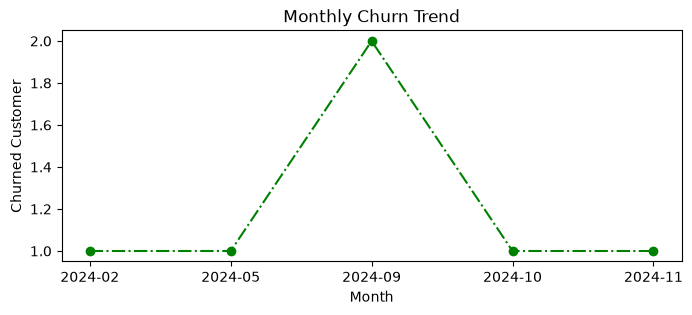

cancellation_date
2024-02    1
2024-05    1
2024-09    2
2024-10    1
2024-11    1
Freq: M, dtype: int64

In [90]:
df1_visual['cancellation_date']=df1_visual['cancellation_date'].dt.to_period('M')
churn_trend=df1_visual[df1_visual['churn_flag']==1].groupby('cancellation_date').size()
plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype('str'),churn_trend.values,color='green',marker='o',linestyle='-.')
plt.title("Monthly Churn Trend")
plt.xlabel("Month")
plt.ylabel("Churned Customer")
plt.show()

churn_trend


<BarContainer object of 3 artists>

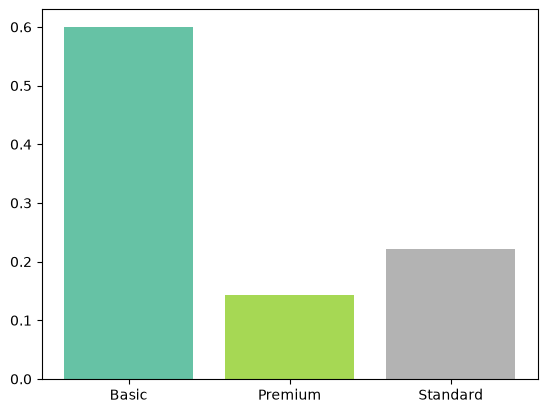

In [92]:
# churn by plan type
churn_plan=df1_visual.groupby('plan_type')['churn_flag'].mean()
colors=plt.cm.Set2(np.linspace(0,1,len(churn_plan)))## samaj nhi aaya bro
plt.bar(churn_plan.index.astype('str'),churn_plan.values,color=colors)

<BarContainer object of 9 artists>

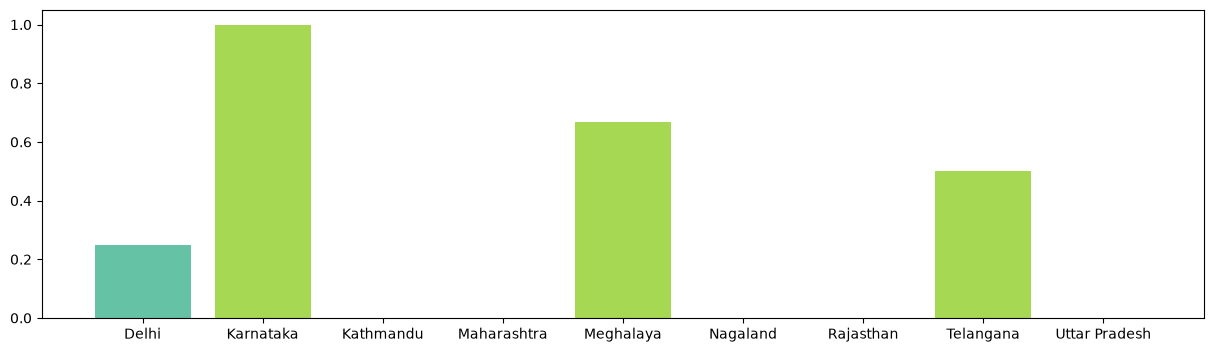

In [93]:
#3 churn by states
churn_states=df1_visual.groupby('state')['churn_flag'].mean()
colors=plt.cm.Set2(np.linspace(0,1,len(churn_plan)))## samaj nhi aaya bro
plt.figure(figsize=(15,4))
plt.bar(churn_states.index.astype('str'),churn_states.values,color=colors)

<BarContainer object of 2 artists>

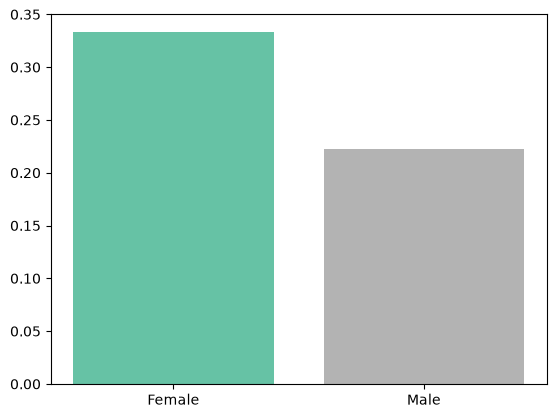

In [94]:
# churn by Gender
churn_gender=df1_visual.groupby('gender')['churn_flag'].mean()
churn_gender
colors=plt.cm.Set2(np.linspace(0,1,len(churn_gender)))
plt.bar(churn_gender.index,churn_gender.values,color=colors)

<BarContainer object of 2 artists>

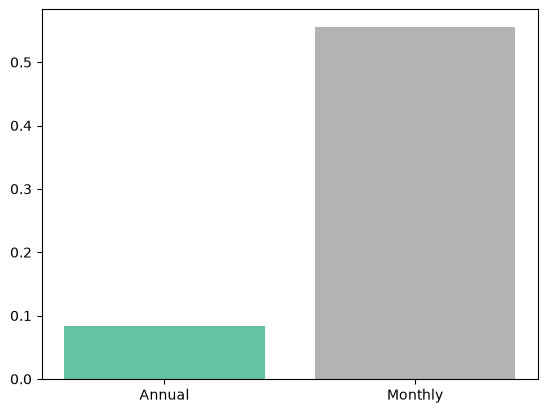

In [96]:
# churn by contract_type
contract_type=df1_visual.groupby('contract_type')['churn_flag'].mean()
contract_type
colors=plt.cm.Set2(np.linspace(0,1,len(contract_type)))
plt.bar(contract_type.index,contract_type.values,color=colors)

In [100]:

df_encoded=df1_visual[[  'plan_type', 'contract_type' ,'churn_score','churn_flag',  'escalations']].head()

categories_cols=['plan_type','contract_type']
for col in categories_cols:
    df_encoded[col]=df_encoded[col].astype('category').cat.codes

In [101]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,escalations
0,2,0,12,0,0
1,1,0,91,1,1
2,0,1,34,0,0
3,1,0,8,0,0
4,2,1,88,1,1


<Axes: >

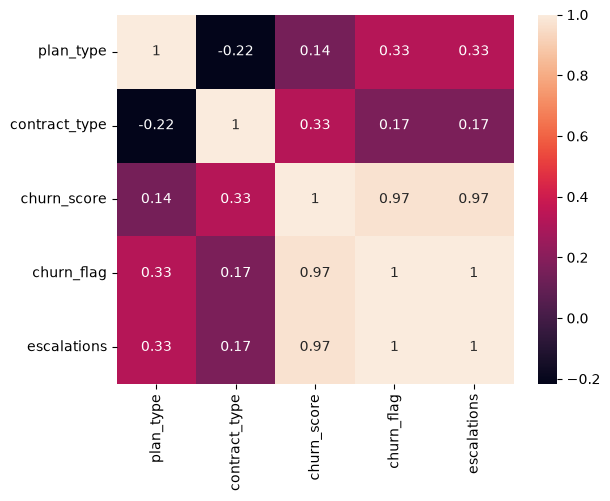

In [102]:
# visualization using seaborn
#Heatmap(correlation matrix)
sns.heatmap(df_encoded.corr(),annot=True)


In [103]:
df1_visual['contract_type'].head().nunique

<bound method IndexOpsMixin.nunique of 0     Annual
1     Annual
2    Monthly
3     Annual
4    Monthly
Name: contract_type, dtype: str>

In [107]:
#pivot tabel in pandas
pd.pivot_table(
    df1_visual,
    index=['plan_type'],
    values=['churn_flag'],
    aggfunc=['mean']
).reset_index()

,plan_type,mean
,,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [109]:
pd.pivot_table(
    df1_visual,
    index=['plan_type'],
    values=['churn_flag','monthly_charges','customerid'],
    aggfunc={
        'churn_flag':'mean',
        'monthly_charges':'sum',
        'customerid':'count'
    }
        
        
        
).reset_index()

,plan_type,churn_flag,customerid,monthly_charges
0,Basic,0.600000,5,52.95
1,Premium,0.142857,7,218.93
2,Standard,0.222222,9,123.91


In [177]:
#Insights

In [ ]:
📄 Customer Churn Analysis Report 
1. Executive Summary
•	Churn Rate: 28.6%
•	Retention Rate: 71.4%
•	Average Tenure: 1,451 days
•	ARPU: ₹18.8
•	Total Revenue: ₹395
•	Revenue Loss due to Churn: ₹74 (18%)
•	CLTV Lost: ₹2,047
2. Churn Breakdown
•	Most churn from Basic plan → minimal revenue impact
•	Monthly vs Annual churn:
o	Monthly: 55.6%
o	Annual: 8.3%
3. Churn Trends
•	Peak churn month: September 2024
•	Most affected state: Karnataka
4. Revenue Impact
•	Pie chart: Revenue retained vs lost
•	Bar chart: CLTV lost due to churn
5. Key Takeaways
•	Strong retention overall (71.4%)
•	Annual plans show much lower churn → promote annual subscriptions
•	Karnataka needs targeted retention strategies
•	Pricing sensitivity evident (“Too expensive” as cancellation reason)
6. Recommendations
•	Incentivize annual plan upgrades
•	Improve content offering for Basic plan users
•	Conduct regional campaigns in Karnataka
•	Monitor churn reasons for proactive action
